# Clockwork-Vol ⏰
### Does the VIX really run on a clock — an 80-day cycle whose lows you can mark weeks ahead?

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Fixed-clock: Not supported](https://img.shields.io/badge/Fixed--clock-Not_supported-8b949e?style=flat-square)

Every so often a chart goes round showing the **VIX moving in tidy cycles**: an 80-day rhythm, a nested 40-day one, lows and highs you can mark on a calendar weeks ahead. The [prompting thread](../docs/references.md) even dated them — a cycle low 'formed May 29', a peak due late July. If volatility really ran on a clock like that, you could *time* it. Here's the catch the eye never sees: a slow, drifting, random series — **red noise** — sprouts exactly these 'cycles' all by itself. So the only honest question is whether the VIX's cycle is taller than the ones pure noise invents.

> 📓 **This is the plain-language layer.** Want the statistics, the microstructure and the capacity maths? That's the companion notebook, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** An educational, reproducible research tool: every chart below is generated by the code beside it. The core runs on a **synthetic** series with a *real* cycle baked in (the cached VIX is git-ignored) — that's where the detector *works*, proving the code, so the flat result on the real VIX (quoted from [`../docs/results.md`](../docs/results.md)) is a fact about the market, not a bug. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))           # study root (vix_cycles/ lives there)
sys.path.insert(0, os.path.abspath("../../.."))      # repo root, for quantlab
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (9.5, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
from vix_cycles import data, spectral, cycles, backtest, robustness

# Offline synthetic log-VIX: a KNOWN fixed cycle (80d & 40d) hidden in AR(1) red noise. This
# is where the detector SHOULD work — so it validates the machinery. The real verdict (the
# VIX, where it does NOT) is in ../docs/results.md via verify_real.py.
series, injected = data.synthetic_cycle(seed=0)
print(f"{len(series)} sessions, injected cycles {[round(c.period) for c in injected]} (a real clock, by construction)")


4000 sessions, injected cycles [80, 40] (a real clock, by construction)


## The answer first 🎯

| What we asked | The honest answer |
|---|---|
| Can the detector find a real cycle? | ✅ **Yes** — on a series with a true 80-day cycle, it lights up well above what noise fakes. |
| Does the VIX's 80/40-day 'cycle' clear that bar? | ❌ **No** — its peaks sit *inside* the red-noise envelope. |
| Does the period stay fixed? | ❌ **No** — the 'dominant cycle' wanders window to window; it has to be re-drawn. |
| Could you trade it? | ❌ **Mostly no** — the adaptive cycle trade loses to buy-and-hold *and* to a scrambled-phase clock. One rescue, hard-wiring the literal **80-day** clock, does clear its own null raw (skill p ≈ 0.03; trade Sharpe 0.69 vs 0.56 buy-and-hold, p ≈ 0.01) — a fragile, single-market fragment from an uncorrected grid of variants, weighed honestly in beat 7. |

> Desk shorthand: **Signal `NONE` · Tradability `MIRAGE`** — let's see the method earn them.

## 1 · The claim 📣

Volatility swings decompose into **fixed-length cycles** — an ~80-session one with a nested ~40-session one — whose lows and highs you can project forward. Mark the last low, add a period, and you know roughly when the next turn is due. Drawn on a chart, it's mesmerising. Let's extract exactly that cycle from a series we *know* has one:

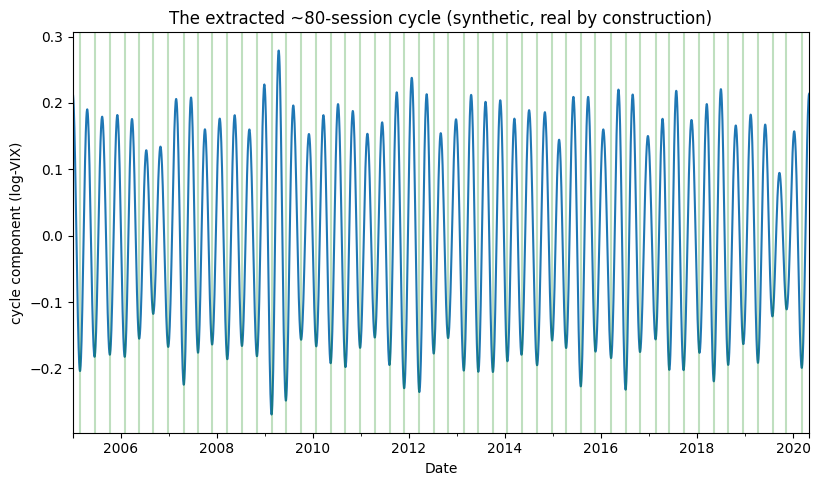

marked 50 cycle lows, ~80 sessions apart


In [2]:
dominant = max(injected, key=lambda c: c.amplitude)
band = cycles.bandpass(series, dominant.period, width_frac=0.4)
tp = cycles.turning_points(series, dominant.period)
ax = band.plot(title=f'The extracted ~{dominant.period:.0f}-session cycle (synthetic, real by construction)')
for d in tp['lows']: ax.axvline(d, color='g', alpha=0.25)
ax.set_ylabel('cycle component (log-VIX)'); plt.show()
print(f"marked {len(tp['lows'])} cycle lows, ~{dominant.period:.0f} sessions apart")

Tidy, isn't it? The whole question is whether the *real* VIX gives you a picture this clean — or whether noise does too.

## 2 · So what? 💰

If volatility ran on a fixed clock, you could time the things that hang off it: buy the dip when the cycle says a vol *peak* (and a stock *low*) is forming, lift hedges when it says calm is due. A reliable 80-day vol clock would be one of the cleanest market-timing edges there is — which is exactly why we should be suspicious of it.

## 3 · How we'd know 🔍

Three tests, announced up front. **(1)** Does the cycle's peak stand above the **red-noise envelope** — the peaks a persistent-but-random series makes on its own? **(2)** Does the period stay **fixed**, or wander? **(3)** Walking forward, does the projected cycle **forecast** the next move better than the same cycle with its timing scrambled? On the synthetic, all three should say *yes* — proving the test works:

In [3]:
env = spectral.red_noise_envelope(series, n_sim=600, seed=0)
peaks = spectral.significant_peaks(env, q=0.99)
print('significant peaks (clear the 99% noise envelope):')
print(peaks.round(3).to_string(index=False) if len(peaks) else '  none')
skill = backtest.oos_direction_skill(series, band=(20,200), horizon=20, min_train=750, n_null=300, seed=0)
print(f"walk-forward direction skill: {skill['skill']:.0%}  (coin=50%, p={skill['p_value']:.3f})")

significant peaks (clear the 99% noise envelope):
 period   power  envelope   ratio
40.0000  7.5540    0.1010 74.7060
80.0000 27.6540    0.5200 53.1480


walk-forward direction skill: 89%  (coin=50%, p=0.047)


## 4 · The teardown 🔬

On the synthetic, the detector nails the real cycle (peaks above the envelope, forecast beats the coin). So the machine is sound. Now the **real VIX**, quoted from the reproducible run ([`../docs/results.md`](../docs/results.md), via `examples/verify_real.py`):

- **The claimed cycles aren't significant.** At 40 and 80 sessions the VIX's periodogram peak sits *inside* the red-noise envelope — noise fakes peaks just as tall (see results.md for the exact p-values).
- **The period won't hold still.** The 'dominant cycle' wanders across a wide range of lengths window to window — the signature of a curve-fit, not a clock.
- **The forecast is a coin flip.** Walking forward, the projected cycle calls the next move no better than chance, and **no better than a random-phase clock**.
- **The rescues mostly don't help** (beat 7): the literal 40-day clock and the amplitude gate change nothing. The literal **80-day** clock is the one flicker that clears its own null raw — beat 7 weighs it against the spectrum it contradicts and the grid of variants it was picked from.

## 5 · The verdict ⚖️

**Signal `NONE`** — the VIX's fixed-period cycles don't clear red noise, and their period doesn't hold. **Tradability `MIRAGE`** — the walk-forward forecast is a coin flip and the cycle trade doesn't beat a scrambled clock. The synthetic proves the detector finds real cycles; the VIX simply isn't one. What looks like a clock is the eye reading rhythm into persistent noise.

## 6 · Could you trade it? 🏦

First, the harness has to pass its own exam. Below we hand it a rigged game: a toy index that rallies tick-for-tick whenever the *planted* vol cycle falls. If the trade harness can't bank that, its silence on the real VIX would mean nothing. It can — fat positive Sharpe, ahead of the scrambled-clock null:

In [4]:
# Positive control: an index that rallies tick-for-tick while the PLANTED vol cycle
# falls. The same harness then judges the real VIX — so it must bank this one.
px = pd.Series(np.exp(np.cumsum(-0.5*np.diff(series.values, prepend=series.values[0]))), index=series.index)
res = backtest.phase_trade(series, px, band=(20,200), min_train=750, n_null=50, seed=0)
print({k: round(v,4) for k,v in res.stats.items() if k in ('sharpe_net','p_value_vs_null','exposure','null_sharpe_p95')})

{'sharpe_net': 4.6893, 'exposure': 0.5858, 'null_sharpe_p95': 4.47, 'p_value_vs_null': 0.0196}


On the **real** S&P (results.md §5) the same harness earns **Sharpe 0.30** — below buy-and-hold's **0.56** and below the random-phase null's own mean (p ≈ 0.88): diluted beta, not timing. You *can't* even buy spot VIX — timing the index off the projected vol cycle is the honest expression, and it adds no information over simply being in the market.

## 7 · Going further 🚪

We didn't leave the rescues as homework — we ran them on the real VIX ([`../docs/extensions.md`](../docs/extensions.md)):

- **Commit to the literal 40d clock** (no re-tuning) — still a coin flip.
- **Commit to the literal 80d clock** — the honest exception: it clears its own null raw (direction skill 0.533, p ≈ 0.026; trade Sharpe 0.69 vs buy-and-hold's 0.56, p ≈ 0.01). But it is one hand-picked period inside an uncorrected grid of looks, it contradicts its own spectrum (no 80-day peak — p ≈ 0.9995), and both legs are cut from the same fit on the same tape. A fragment to pre-register out-of-sample, not a clock.
- **Only trade when a strong cycle is visible** (amplitude gate) — the gate never fires in 36 years (exposure 0; Sharpe undefined): there is never a 'strong, clear cycle' to wait for.
- **Is the cycle in *stocks* instead?** The S&P's 20-week and 4-year clocks don't clear red noise either.

Still open: longer VIX-futures-term-structure cycles, and a formal wavelet time-localization. The deep version — the envelope, the p-values, the walk-forward and the trade — is in [`02_for_the_quants.ipynb`](02_for_the_quants.ipynb).